# Imports

In [13]:

print ("ahemd khelad")



ahemd khelad


# Load Dataset

In [16]:

print ("ahemd")

print(df.head())
print(df.columns)

ahemd
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        

# Feature and Data preprocessing

In [3]:
df = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Survived"]]

df["Sex"] = df["Sex"].str.lower()
df["Sex"] = (df["Sex"] == "female").astype(int)# to make (male = 1) and (female = 0)

# معالجة Age and Fare and Embarked
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

df["Embarked"] = df["Embarked"].fillna("S")
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# تأكد مفيش NaN
print(df.isnull().sum())

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64


# Extra Features

In [4]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df = df[["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone", "Survived"]]# Final Features Selection

print(df.isnull().sum())

Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
Survived      0
dtype: int64


# Split X and Y

In [5]:
X = df.drop("Survived", axis=1).values
Y = df["Survived"].values

# Normalize

In [6]:
X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)

# Reshape for NN

In [7]:
X = X.T
Y = Y.reshape(1, -1)

print(X.shape, Y.shape)

(7, 891) (1, 891)


# 🧠 Neural Network

# Activation Functions

In [8]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def relu(Z):
    return np.maximum(0, Z)

def sigmoid_backward(dA, Z):
    s = sigmoid(Z)
    return dA * s * (1 - s)

def relu_backward(dA, Z):
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

# Forward Propagation

In [9]:
def forward_propagation(X, parameters):
    caches = {}
    A = X
    caches["A0"] = A
    
    L = len(parameters) // 2

    for l in range(1, L):
        W = parameters["W" + str(l)]
        b = parameters["b" + str(l)]
        
        Z = np.dot(W, A) + b
        A = relu(Z)
        
        caches["Z" + str(l)] = Z
        caches["A" + str(l)] = A

    # Output layer
    WL = parameters["W" + str(L)]
    bL = parameters["b" + str(L)]
    
    ZL = np.dot(WL, A) + bL
    AL = sigmoid(ZL)
    
    caches["Z" + str(L)] = ZL
    caches["A" + str(L)] = AL

    return AL, caches

# Backpropagation

In [10]:
def backward_propagation(X, Y, parameters, caches):
    grads = {}
    m = X.shape[1]
    L = len(parameters) // 2

    AL = caches["A" + str(L)]
    
    dZL = AL - Y
    grads["dW" + str(L)] = (1/m) * np.dot(dZL, caches["A" + str(L-1)].T)
    grads["db" + str(L)] = (1/m) * np.sum(dZL, axis=1, keepdims=True)

    dA_prev = np.dot(parameters["W" + str(L)].T, dZL)

    for l in reversed(range(1, L)):
        dZ = relu_backward(dA_prev, caches["Z" + str(l)])
        
        grads["dW" + str(l)] = (1/m) * np.dot(dZ, caches["A" + str(l-1)].T)
        grads["db" + str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        dA_prev = np.dot(parameters["W" + str(l)].T, dZ)

    return grads

# Update Parameters

In [11]:
def update_parameters(parameters, grads, learning_rate=0.05):
    L = len(parameters) // 2

    for l in range(1, L+1):
        parameters["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]

    return parameters

# Initialize Parameters

In [12]:
np.random.seed(1)

parameters = {
    "W1": np.random.randn(8, 7) * np.sqrt(2/7), "b1": np.zeros((8, 1)),
    "W2": np.random.randn(5, 8) * np.sqrt(2/8), "b2": np.zeros((5, 1)),
    "W3": np.random.randn(1, 5) * np.sqrt(2/5), "b3": np.zeros((1, 1))
}

# Training Loop

In [13]:
losses = []
accuracies = []

for i in range(5000):

    AL, caches = forward_propagation(X, parameters)
    grads = backward_propagation(X, Y, parameters, caches)
    parameters = update_parameters(parameters, grads, learning_rate=0.01)

    # Loss
    loss = -(1/X.shape[1]) * np.sum(
        Y*np.log(AL + 1e-8) + (1-Y)*np.log(1-AL + 1e-8)
    )

    # Accuracy
    preds = (AL > 0.5).astype(int)
    acc = np.mean(preds == Y)

    # Save
    losses.append(loss)
    accuracies.append(acc)

    if i % 500 == 0:
        print(f"Iteration {i}, Loss: {loss:.4f}")

Iteration 0, Loss: 0.6996
Iteration 500, Loss: 0.5727
Iteration 1000, Loss: 0.5052
Iteration 1500, Loss: 0.4635
Iteration 2000, Loss: 0.4447
Iteration 2500, Loss: 0.4331
Iteration 3000, Loss: 0.4249
Iteration 3500, Loss: 0.4195
Iteration 4000, Loss: 0.4157
Iteration 4500, Loss: 0.4123


# Loss Curve

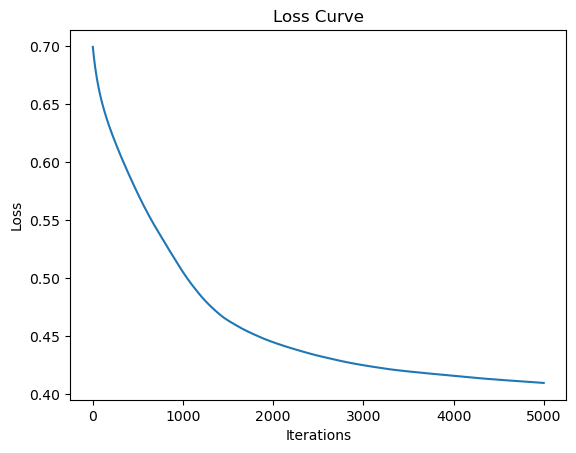

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

# Accuracy

In [15]:
preds = (AL > 0.5).astype(int)
accuracy = np.mean(preds == Y)

print("Accuracy:", accuracy )

Accuracy: 0.8282828282828283
